
═══════════ 1. DATA LOADING & INITIAL INSPECTION ═══════════
📊 Dimensi Dataset: 891 baris, 8 kolom

🔍 Jumlah Missing Values Per Kolom:
          Missing Count  Percentage (%)
age                 177           19.87
embarked              2            0.22

🎯 Distribusi Target (Survived):
          Jumlah  Proporsi
survived                  
0            549     0.616
1            342     0.384


/tmp/ipykernel_4536/2424265668.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Meninggal', 'Selamat'])


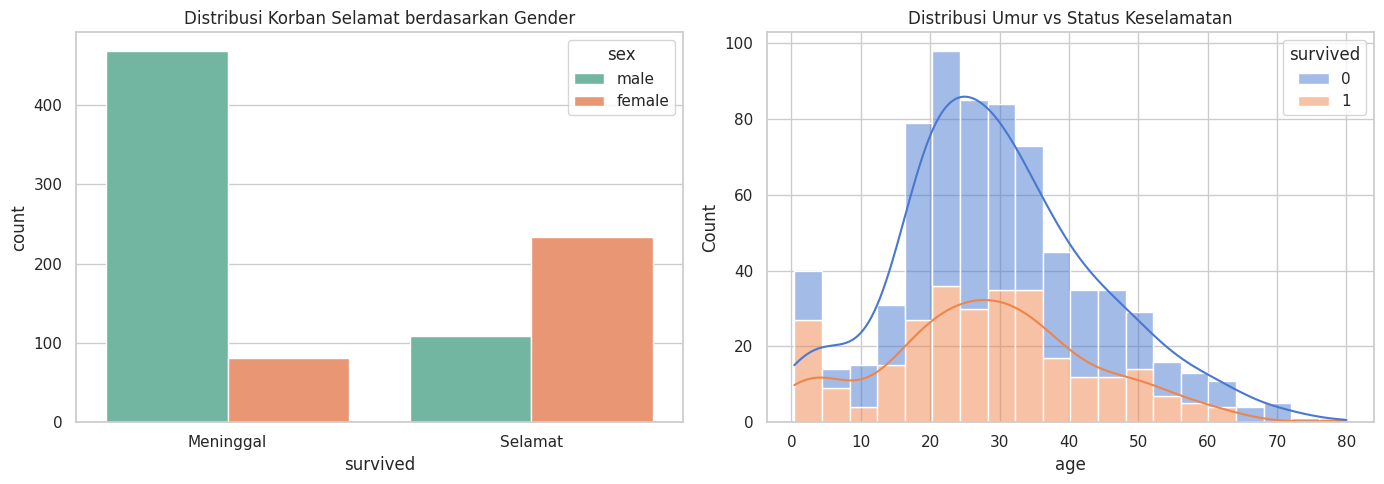

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

def print_header(title):
    print("\n" + "="*60)
    print(f" {title.upper()} ".center(60, "═"))
    print("="*60)

# ==========================================
# 1. LOAD & INSPECT DATA
# ==========================================
df = sns.load_dataset('titanic')
cols = ['pclass','sex','age','sibsp','parch','fare','embarked','survived']
df = df[cols].copy()

print_header("1. Data Loading & Initial Inspection")
print(f"📊 Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

print('\n🔍 Jumlah Missing Values Per Kolom:')
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data[missing_data['Missing Count'] > 0])

print('\n🎯 Distribusi Target (Survived):')
dist_target = pd.DataFrame({
    'Jumlah': df['survived'].value_counts(),
    'Proporsi': df['survived'].value_counts(normalize=True).round(3)
})
print(dist_target)

# Visualisasi 1: Distribusi Target & Missing Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='survived', hue='sex', palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Korban Selamat berdasarkan Gender')
axes[0].set_xticklabels(['Meninggal', 'Selamat'])

sns.histplot(data=df, x='age', hue='survived', multiple='stack', palette='muted', kde=True, ax=axes[1])
axes[1].set_title('Distribusi Umur vs Status Keselamatan')
plt.tight_layout()
plt.show()

In [2]:
# ==========================================
# 2. HANDLING MISSING VALUES
# ==========================================
print_header("2. Handling Missing Values")
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('✅ Imputasi Selesai. Status Missing Value Terbaru:')
print(f"Total Missing Values: {df.isnull().sum().sum()}")


════════════════ 2. HANDLING MISSING VALUES ════════════════
✅ Imputasi Selesai. Status Missing Value Terbaru:
Total Missing Values: 0


In [3]:
# ==========================================
# 3. CATEGORICAL ENCODING
# ==========================================
print_header("3. Categorical Encoding (One-Hot Encoding)")
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=int)
print('🚀 Kolom setelah encoding (Siap Numerik):')
for col in df.columns.tolist():
    print(f" - {col}")


════════ 3. CATEGORICAL ENCODING (ONE-HOT ENCODING) ════════
🚀 Kolom setelah encoding (Siap Numerik):
 - pclass
 - age
 - sibsp
 - parch
 - fare
 - survived
 - sex_male
 - embarked_Q
 - embarked_S


In [4]:
# ==========================================
# 4. TRAIN-TEST SPLIT
# ==========================================
print_header("4. Data Splitting (Train & Test)")
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

split_summary = pd.DataFrame({
    'Dataset': ['Train Set', 'Test Set'],
    'Jumlah Baris': [X_train.shape[0], X_test.shape[0]],
    'Proporsi Selamat (1)': [
        f"{y_train.value_counts(normalize=True)[1]:.1%}",
        f"{y_test.value_counts(normalize=True)[1]:.1%}"
    ],
    'Proporsi Meninggal (0)': [
        f"{y_train.value_counts(normalize=True)[0]:.1%}",
        f"{y_test.value_counts(normalize=True)[0]:.1%}"
    ]
})
print(split_summary.to_string(index=False))


═════════════ 4. DATA SPLITTING (TRAIN & TEST) ═════════════
  Dataset  Jumlah Baris Proporsi Selamat (1) Proporsi Meninggal (0)
Train Set           712                38.3%                  61.7%
 Test Set           179                38.5%                  61.5%


In [5]:
# ==========================================
# 5. FEATURE SCALING
# ==========================================
print_header("5. Feature Scaling (StandardScaler)")
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

scaler_info = pd.DataFrame({
    'Fitur': num_cols,
    'Mean (Train)': scaler.mean_.round(2),
    'Std Dev (Train)': scaler.scale_.round(2)
})
print("📈 Parameter Scaler:")
print(scaler_info.to_string(index=False))

print('\n👀 Cuplikan 3 Baris Pertama X_train (Setelah Scaling):')
print(X_train.head(3).round(3))


═══════════ 5. FEATURE SCALING (STANDARDSCALER) ════════════
📈 Parameter Scaler:
 Fitur  Mean (Train)  Std Dev (Train)
pclass          2.31             0.83
   age         29.46            13.03
 sibsp          0.49             1.06
 parch          0.39             0.84
  fare         31.82            48.03

👀 Cuplikan 3 Baris Pertama X_train (Setelah Scaling):
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1


In [6]:
# ==========================================
# CONCLUSION
# ==========================================
print("\n" + "🎉".center(60, "-"))
print(" STATUS: DATA SIAP DILATIH MODEL MACHINE LEARNING! ".center(60, " "))
print("═"*60)
print(f" 📂 X_train Matriks: {X_train.shape}  |  🎯 y_train Target: {y_train.shape}")
print(f" 📂 X_test Matriks : {X_test.shape}  |  🎯 y_test Target : {y_test.shape}")
print("═"*60)


-----------------------------🎉------------------------------
     STATUS: DATA SIAP DILATIH MODEL MACHINE LEARNING!      
════════════════════════════════════════════════════════════
 📂 X_train Matriks: (712, 8)  |  🎯 y_train Target: (712,)
 📂 X_test Matriks : (179, 8)  |  🎯 y_test Target : (179,)
════════════════════════════════════════════════════════════
